# Synthetic Data Generator — Julius Baer AML/KYC TM Tool
## MH6822 Regulatory Technology — Assignment 1

---

## Purpose of This File

This notebook generates **all synthetic transaction data** used by the main TM tool.

**Run this notebook FIRST before the main TM tool notebook.**

Outputs:
- `../data/Task3_SyntheticData_AllScenarios.csv`
- `../outputs/Task3_ScenarioOverview.png`

---

## Folder Structure Expected
```
Assignment1_JuliusBaer_AML/
├── data/           <- CSV output lands here
├── notebooks/      <- You are here (run from this folder)
│   ├── Task3_SyntheticData_Generator.ipynb   (run first)
│   └── Task3_JuliusBaer_AML_TM_Tool.ipynb   (run second)
└── outputs/        <- Charts land here
```

---

## 8 Scenarios

| Scenario | Structure | Typology | Complexity |
|---|---|---|---|
| S1 | Simple Individual | Clean baseline | Simple |
| S2 | Simple Individual | Structuring / smurfing | Simple |
| S3 | PEP Individual | Legitimate high-risk client | Simple |
| S4 | BVI Holdco + Personal | Layering via inter-entity transfer | Complex |
| S5 | Cayman Fund | Early redemption / integration | Complex |
| S6 | Family Trust + Foundation | Source of wealth obscuring | Complex |
| S7 | Multi-entity HNWI | 5 accounts, 3 jurisdictions | Complex |
| S8 | Corporate Operating Account | Co-mingling + domestic PEP | Complex |

**All data is entirely synthetic and inspired by typical real world corporate data in PB. No real client or transaction data is used.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Notebooks live in /notebooks/ — go one level up for data/ and outputs/
BASE_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR   = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Base    : {BASE_DIR}')
print(f'Data    : {DATA_DIR}')
print(f'Outputs : {OUTPUT_DIR}')
print('Paths OK.')

Base    : c:\Users\User\Downloads\Assignment 1_G2508087C
Data    : c:\Users\User\Downloads\Assignment 1_G2508087C\data
Outputs : c:\Users\User\Downloads\Assignment 1_G2508087C\outputs
Paths OK.


---
## S1 — Simple Individual, Clean Baseline
```
Ms. Sarah Tan (SG resident, Low Risk)
└── Personal Account (JB Singapore)
```
**Presentation:** GREEN control group. Shows tool does not over-fire.
Talking point: *'Not all large transactions are suspicious — context matters.'

In [2]:
s1_base = dict(client_id='JB-S1-001', client_name='Sarah Tan Mei Ling',
               client_type='Individual', risk_tier='Low',
               is_pep=False, is_domestic_pep=False, bo_pct=100,
               booking_centre='SG', scenario='S1', typology='Clean Baseline',
               velocity_30d=2, is_round_number=False,
               is_structured_attempt=False, is_high_risk_cp_country=False, is_inter_entity=False,
               presentation_note='GREEN — tool correctly passes clean transactions; baseline for comparison')

s1_txns = [
    dict(tx_id='TX-S1-001', tx_type='Dividend Receipt',    amount_usd=45000,  counterparty_country='US', note='Quarterly dividend from US equity holding'),
    dict(tx_id='TX-S1-002', tx_type='Currency Exchange',   amount_usd=28000,  counterparty_country='SG', note='USD to SGD conversion for local expenses'),
    dict(tx_id='TX-S1-003', tx_type='Wire Transfer',       amount_usd=15000,  counterparty_country='GB', note='Tuition fee to UK university'),
    dict(tx_id='TX-S1-004', tx_type='Investment Transfer', amount_usd=100000, counterparty_country='SG', note='Portfolio rebalancing within JB Singapore'),
    dict(tx_id='TX-S1-005', tx_type='Wire Transfer',       amount_usd=8000,   counterparty_country='SG', note='Monthly living expenses'),
]
s1_df = pd.DataFrame([{**s1_base, **t} for t in s1_txns])
print(f'S1 — {len(s1_df)} transactions | Clean Baseline')
s1_df[['tx_id','tx_type','amount_usd','counterparty_country','note']]

S1 — 5 transactions | Clean Baseline


,tx_id,tx_type,amount_usd,counterparty_country,note
0,TX-S1-001,Dividend Receipt,45000,US,Quarterly dividend from US equity holding
1,TX-S1-002,Currency Exchange,28000,SG,USD to SGD conversion for local expenses
2,TX-S1-003,Wire Transfer,15000,GB,Tuition fee to UK university
3,TX-S1-004,Investment Transfer,100000,SG,Portfolio rebalancing within JB Singapore
4,TX-S1-005,Wire Transfer,8000,SG,Monthly living expenses


---
## S2 — Simple Individual, Structuring / Smurfing
```
Mr. David Lim (SG resident, Medium Risk)
└── Personal Account (JB Singapore)
    └── 4 x cash deposits just below USD 10,000 → bulk wire out
```
**Presentation:** Core US vs SG divergence slide.
US = mandatory CTR above USD 10,000; structuring below it is a federal offence.
SG = no fixed threshold; tool generates risk narrative explaining the pattern.
Same transactions — two completely different regulatory responses.

In [3]:
s2_base = dict(client_id='JB-S2-001', client_name='David Lim Boon Keng',
               client_type='Individual', risk_tier='Medium',
               is_pep=False, is_domestic_pep=False, bo_pct=100,
               booking_centre='SG', scenario='S2', typology='Structuring / Smurfing',
               velocity_30d=8, is_round_number=False,
               is_high_risk_cp_country=False, is_inter_entity=False,
               presentation_note='RED — demonstrates US CTR vs SG risk-narrative divergence on identical transactions')

s2_txns = [
    dict(tx_id='TX-S2-001', tx_type='Cash Deposit',  amount_usd=9800,  counterparty_country='SG', is_structured_attempt=True,  note='Day 1: cash deposit just below USD 10,000 CTR threshold'),
    dict(tx_id='TX-S2-002', tx_type='Cash Deposit',  amount_usd=9500,  counterparty_country='SG', is_structured_attempt=True,  note='Day 2: repeated pattern, different branch'),
    dict(tx_id='TX-S2-003', tx_type='Cash Deposit',  amount_usd=9700,  counterparty_country='SG', is_structured_attempt=True,  note='Day 3: third consecutive sub-threshold deposit'),
    dict(tx_id='TX-S2-004', tx_type='Cash Deposit',  amount_usd=9200,  counterparty_country='SG', is_structured_attempt=True,  note='Day 4: cumulative total now USD 38,200'),
    dict(tx_id='TX-S2-005', tx_type='Wire Transfer', amount_usd=38000, counterparty_country='MY', is_structured_attempt=False, note='Day 7: bulk transfer to Malaysia after deposits settle — integration'),
]
s2_df = pd.DataFrame([{**s2_base, **t} for t in s2_txns])
print(f'S2 — {len(s2_df)} transactions | Structuring')
s2_df[['tx_id','tx_type','amount_usd','is_structured_attempt','note']]

S2 — 5 transactions | Structuring


,tx_id,tx_type,amount_usd,is_structured_attempt,note
0,TX-S2-001,Cash Deposit,9800,True,"Day 1: cash deposit just below USD 10,000 CTR ..."
1,TX-S2-002,Cash Deposit,9500,True,"Day 2: repeated pattern, different branch"
2,TX-S2-003,Cash Deposit,9700,True,Day 3: third consecutive sub-threshold deposit
3,TX-S2-004,Cash Deposit,9200,True,"Day 4: cumulative total now USD 38,200"
4,TX-S2-005,Wire Transfer,38000,False,Day 7: bulk transfer to Malaysia after deposit...


---
## S3 — PEP Individual, Legitimate Flows
```
Mr. Rajesh Subramaniam (Indian national, SG resident)
Former Finance Minister India — Foreign PEP under both US and SG rules
└── Personal Account (JB Singapore)
    └── Legitimate post-retirement investment income + board fees
```
**Presentation:** PEP divergence + false positive risk.
10-15% of Julius Baer clients are PEPs — this is normal.
Tool requires EDD but does NOT auto-file SAR/STR — human judgement preserved.
Foreign PEP: EDD in both US and SG.
Domestic PEP equivalent: EDD in SG only (see S8).

In [4]:
s3_base = dict(client_id='JB-S3-001', client_name='Rajesh Subramaniam',
               client_type='Individual', risk_tier='High',
               is_pep=True, is_domestic_pep=False, bo_pct=100,
               booking_centre='SG', scenario='S3', typology='PEP — Legitimate High-Risk Client',
               velocity_30d=3, is_round_number=False,
               is_high_risk_cp_country=False, is_structured_attempt=False, is_inter_entity=False,
               presentation_note='AMBER — PEP EDD required; transactions are explainable; shows false positive risk and PEP scope divergence')

s3_txns = [
    dict(tx_id='TX-S3-001', tx_type='Dividend Receipt',    amount_usd=120000, counterparty_country='IN', note='Annual dividend from Indian family business — source of wealth documented'),
    dict(tx_id='TX-S3-002', tx_type='Wire Transfer',       amount_usd=55000,  counterparty_country='SG', note='Board director fee from SG-listed company'),
    dict(tx_id='TX-S3-003', tx_type='Investment Transfer', amount_usd=200000, counterparty_country='US', note='Subscription to US PE fund — KYC and source of funds on file'),
    dict(tx_id='TX-S3-004', tx_type='Currency Exchange',   amount_usd=30000,  counterparty_country='SG', note='INR to USD FX — remittance from India family account'),
]
s3_df = pd.DataFrame([{**s3_base, **t} for t in s3_txns])
print(f'S3 — {len(s3_df)} transactions | PEP Legitimate')
s3_df[['tx_id','tx_type','amount_usd','counterparty_country','note']]

S3 — 4 transactions | PEP Legitimate


,tx_id,tx_type,amount_usd,counterparty_country,note
0,TX-S3-001,Dividend Receipt,120000,IN,Annual dividend from Indian family business — ...
1,TX-S3-002,Wire Transfer,55000,SG,Board director fee from SG-listed company
2,TX-S3-003,Investment Transfer,200000,US,Subscription to US PE fund — KYC and source of...
3,TX-S3-004,Currency Exchange,30000,SG,INR to USD FX — remittance from India family a...


---
## S4 — BVI Holdco + Personal Account, Layering
```
Mr. Viktor Petrov (Russian national, UAE resident)
├── Personal Account              JB Singapore  ← destination of cleaned funds
└── Petrov Capital Ltd (BVI)      JB Singapore  ← layering vehicle
    ├── Receives USD 500K from Russia (no contract)
    ├── Receives USD 320K from Cyprus shell
    ├── Transfers USD 750K to personal account (no rationale) ← INTER-ENTITY
    └── Personal account wires USD 700K to UAE within 48hrs   ← INTEGRATION
```
**Presentation:** SHOWSTOPPER — why private bank TM is fundamentally different.
Retail TM tool sees two separate clean accounts.
Our tool links them via beneficial owner ID — the inter-entity transfer
with no commercial rationale is only visible at the entity level.
This is what NICE Actimize misses.

In [6]:
s4_txns = [
    dict(tx_id='TX-S4-001', client_id='JB-S4-001-C', client_name='Petrov Capital Ltd (BVI)',
         client_type='Corporate', risk_tier='High', is_pep=False, is_domestic_pep=False,
         bo_pct=15, booking_centre='SG',
         tx_type='Wire Transfer', amount_usd=500000, counterparty_country='RU',
         is_high_risk_cp_country=True,  is_inter_entity=False,
         is_structured_attempt=False, is_round_number=True, velocity_30d=6,
         note='HOLDCO INFLOW: Large credit from Russia — no commercial contract on file'),

    dict(tx_id='TX-S4-002', client_id='JB-S4-001-C', client_name='Petrov Capital Ltd (BVI)',
         client_type='Corporate', risk_tier='High', is_pep=False, is_domestic_pep=False,
         bo_pct=15, booking_centre='SG',
         tx_type='Wire Transfer', amount_usd=320000, counterparty_country='CY',
         is_high_risk_cp_country=False, is_inter_entity=False,
         is_structured_attempt=False, is_round_number=True, velocity_30d=6,
         note='HOLDCO INFLOW: Credit from Cyprus shell — possible pass-through'),

    dict(tx_id='TX-S4-003', client_id='JB-S4-001-C', client_name='Petrov Capital Ltd (BVI)',
         client_type='Corporate', risk_tier='High', is_pep=False, is_domestic_pep=False,
         bo_pct=15, booking_centre='SG',
         tx_type='Wire Transfer', amount_usd=750000, counterparty_country='SG',
         is_high_risk_cp_country=False, is_inter_entity=True,
         is_structured_attempt=False, is_round_number=True, velocity_30d=6,
         note='INTER-ENTITY: BVI holdco → personal account. No dividend resolution, no loan agreement — LAYERING INDICATOR'),

    dict(tx_id='TX-S4-004', client_id='JB-S4-001-P', client_name='Viktor Petrov',
         client_type='Individual', risk_tier='High', is_pep=False, is_domestic_pep=False,
         bo_pct=100, booking_centre='SG',
         tx_type='Wire Transfer', amount_usd=700000, counterparty_country='AE',
         is_high_risk_cp_country=False, is_inter_entity=False,
         is_structured_attempt=False, is_round_number=True, velocity_30d=4,
         note='PERSONAL OUTFLOW: Majority wired to UAE within 48hrs — integration stage'),
]
for t in s4_txns:
    t.update(scenario='S4', typology='Layering — BVI Holdco Inter-Entity Transfer',
             presentation_note='RED — showstopper; entity-linkage catches what retail tools miss; BO 15% below MAS threshold')
s4_df = pd.DataFrame(s4_txns)
print(f'S4 — {len(s4_df)} transactions across 2 linked accounts | Layering')
s4_df[['tx_id','client_id','amount_usd','counterparty_country','is_inter_entity','note']]

S4 — 4 transactions across 2 linked accounts | Layering


,tx_id,client_id,amount_usd,counterparty_country,is_inter_entity,note
0,TX-S4-001,JB-S4-001-C,500000,RU,False,HOLDCO INFLOW: Large credit from Russia — no c...
1,TX-S4-002,JB-S4-001-C,320000,CY,False,HOLDCO INFLOW: Credit from Cyprus shell — poss...
2,TX-S4-003,JB-S4-001-C,750000,SG,True,INTER-ENTITY: BVI holdco → personal account. N...
3,TX-S4-004,JB-S4-001-P,700000,AE,False,PERSONAL OUTFLOW: Majority wired to UAE within...


---
## S5 — Cayman Fund, Early Redemption / Integration
```
Ms. Chen Xiaoming (Chinese national, HK resident)
└── Cayman Fund Subscription Account (JB HK)
    ├── Day 0:  USD 2M deposited from China
    ├── Day 3:  USD 2M subscribed to Cayman hedge fund
    ├── Day 48: Redeems early at 8% LOSS (USD 160K loss accepted)
    └── Day 49: Proceeds wired to SG — now appear as clean investment income
```
**Presentation:** Why ML + rules together.
No rule catches this — it looks like a bad investment.
But no rational HNWI accepts an 8% loss in 45 days unless paying to clean money.
Isolation Forest flags the statistical anomaly. SHAP explains why.

In [7]:
s5_base = dict(client_id='JB-S5-001', client_name='Chen Xiaoming',
               client_type='Individual', risk_tier='High',
               is_pep=False, is_domestic_pep=False, bo_pct=100,
               booking_centre='HK', scenario='S5', typology='Early Redemption — Integration via Fund',
               velocity_30d=7, is_structured_attempt=False, is_inter_entity=False,
               presentation_note='RED — invisible to rule-based tools; caught by anomaly detection; demonstrates ML layer value')

s5_txns = [
    dict(tx_id='TX-S5-001', tx_type='Cash Deposit',       amount_usd=2000000, counterparty_country='CN', is_high_risk_cp_country=False, is_round_number=True,  note='Day 0: Large deposit from China — source of funds unclear'),
    dict(tx_id='TX-S5-002', tx_type='Investment Transfer', amount_usd=2000000, counterparty_country='KY', is_high_risk_cp_country=False, is_round_number=True,  note='Day 3: Full amount subscribed to Cayman hedge fund immediately'),
    dict(tx_id='TX-S5-003', tx_type='Investment Transfer', amount_usd=1840000, counterparty_country='KY', is_high_risk_cp_country=False, is_round_number=False, note='Day 48: Early redemption at 8% loss — USD 160K loss accepted with no market justification'),
    dict(tx_id='TX-S5-004', tx_type='Wire Transfer',       amount_usd=1800000, counterparty_country='SG', is_high_risk_cp_country=False, is_round_number=True,  note='Day 49: Proceeds immediately wired to SG — funds now appear as clean investment income'),
]
s5_df = pd.DataFrame([{**s5_base, **t} for t in s5_txns])
print(f'S5 — {len(s5_df)} transactions | Early Redemption')
s5_df[['tx_id','tx_type','amount_usd','counterparty_country','note']]

S5 — 4 transactions | Early Redemption


,tx_id,tx_type,amount_usd,counterparty_country,note
0,TX-S5-001,Cash Deposit,2000000,CN,Day 0: Large deposit from China — source of fu...
1,TX-S5-002,Investment Transfer,2000000,KY,Day 3: Full amount subscribed to Cayman hedge ...
2,TX-S5-003,Investment Transfer,1840000,KY,Day 48: Early redemption at 8% loss — USD 160K...
3,TX-S5-004,Wire Transfer,1800000,SG,Day 49: Proceeds immediately wired to SG — fun...


---
## S6 — Family Trust + Foundation, Source of Wealth Obscuring
```
Mr. Abdullah Al-Rashid (UAE national — Foreign PEP)
├── Al-Rashid Family Trust (Jersey)      JB Singapore
│   └── Funded by UAE government-linked entity
└── Al-Rashid Foundation (Panama)        JB Singapore
    ├── Receives 'donations' from Panama entity
    └── Makes 'grants' to Myanmar entity (FATF high-risk)
```
**Presentation:** BO threshold divergence US vs SG.
BO disclosed at 15% — passes US FinCEN 25% flat threshold.
Fails MAS Notice 626 risk-based threshold of 10-15% for high-risk clients.
Same structure, different outcome depending on booking centre.

In [8]:
s6_txns = [
    dict(tx_id='TX-S6-001', client_id='JB-S6-001-T', client_name='Al-Rashid Family Trust',
         client_type='Trust', risk_tier='High', is_pep=True, is_domestic_pep=False,
         bo_pct=15, booking_centre='SG',
         tx_type='Wire Transfer', amount_usd=850000, counterparty_country='AE',
         is_high_risk_cp_country=False, is_inter_entity=False,
         is_structured_attempt=False, is_round_number=False, velocity_30d=4,
         note='TRUST INFLOW: UAE government-linked investment authority. PEP. Source of funds requires EDD.'),

    dict(tx_id='TX-S6-002', client_id='JB-S6-001-F', client_name='Al-Rashid Foundation (Panama)',
         client_type='Foundation', risk_tier='High', is_pep=True, is_domestic_pep=False,
         bo_pct=15, booking_centre='SG',
         tx_type='Wire Transfer', amount_usd=400000, counterparty_country='PA',
         is_high_risk_cp_country=False, is_inter_entity=False,
         is_structured_attempt=False, is_round_number=True, velocity_30d=3,
         note='FOUNDATION INFLOW: Donation from Panama entity. Charitable purpose unverified. Panama + foundation = layering risk.'),

    dict(tx_id='TX-S6-003', client_id='JB-S6-001-F', client_name='Al-Rashid Foundation (Panama)',
         client_type='Foundation', risk_tier='High', is_pep=True, is_domestic_pep=False,
         bo_pct=15, booking_centre='SG',
         tx_type='Wire Transfer', amount_usd=380000, counterparty_country='MM',
         is_high_risk_cp_country=True, is_inter_entity=False,
         is_structured_attempt=False, is_round_number=True, velocity_30d=3,
         note='FOUNDATION OUTFLOW: Grant to Myanmar entity — FATF high-risk. No charitable project documentation.'),

    dict(tx_id='TX-S6-004', client_id='JB-S6-001-T', client_name='Al-Rashid Family Trust',
         client_type='Trust', risk_tier='High', is_pep=True, is_domestic_pep=False,
         bo_pct=15, booking_centre='SG',
         tx_type='Wire Transfer', amount_usd=600000, counterparty_country='SG',
         is_high_risk_cp_country=False, is_inter_entity=True,
         is_structured_attempt=False, is_round_number=True, velocity_30d=4,
         note='INTER-ENTITY: Trust → personal account. No trustee resolution. BO 15% — below MAS high-risk threshold.'),
]
for t in s6_txns:
    t.update(scenario='S6', typology='Source of Wealth Obscuring — Trust/Foundation',
             presentation_note='RED — BO 15% passes US FinCEN 25%; fails MAS high-risk threshold; PEP + Myanmar = compounding flags')
s6_df = pd.DataFrame(s6_txns)
print(f'S6 — {len(s6_df)} transactions across 2 linked entities | SOW Obscuring')
s6_df[['tx_id','client_id','amount_usd','counterparty_country','is_inter_entity','note']]

S6 — 4 transactions across 2 linked entities | SOW Obscuring


,tx_id,client_id,amount_usd,counterparty_country,is_inter_entity,note
0,TX-S6-001,JB-S6-001-T,850000,AE,False,TRUST INFLOW: UAE government-linked investment...
1,TX-S6-002,JB-S6-001-F,400000,PA,False,FOUNDATION INFLOW: Donation from Panama entity...
2,TX-S6-003,JB-S6-001-F,380000,MM,False,FOUNDATION OUTFLOW: Grant to Myanmar entity — ...
3,TX-S6-004,JB-S6-001-T,600000,SG,True,INTER-ENTITY: Trust → personal account. No tru...


---
## S7 — Multi-Entity HNWI (5 accounts, 3 jurisdictions)
```
Mr. James Thornton (British national, SG resident — Ultra HNWI)
├── Personal Account                    JB Singapore   MAS Notice 626
├── Thornton Holdings Ltd (Cayman)      JB Singapore   MAS Notice 626
├── Thornton Family Trust (Jersey)      JB Singapore   MAS Notice 626
├── JT Capital LLC (Delaware, US)       JB New York    FinCEN / BSA
└── Thornton Charitable Foundation (SG) JB Singapore   MAS Notice 626
```
**Presentation:** Full private bank reality.
One client. Five accounts. Three jurisdictions. One tool.
US Delaware LLC → Cayman holdco with no documentation = RED in both jurisdictions.
Foundation grant to verified SG charity = GREEN.
Tool handles all of this simultaneously.

In [9]:
s7_txns = [
    dict(tx_id='TX-S7-001', client_id='JB-S7-001-US', client_name='JT Capital LLC (Delaware)',
         client_type='Corporate', risk_tier='Medium', is_pep=False, is_domestic_pep=False,
         bo_pct=100, booking_centre='US',
         tx_type='Wire Transfer', amount_usd=250000, counterparty_country='GB',
         is_high_risk_cp_country=False, is_inter_entity=False,
         is_structured_attempt=False, is_round_number=True, velocity_30d=2,
         note='US LLC: Management fee from UK subsidiary — agreement on file. FinCEN rules apply. GREEN.'),

    dict(tx_id='TX-S7-002', client_id='JB-S7-001-US', client_name='JT Capital LLC (Delaware)',
         client_type='Corporate', risk_tier='Medium', is_pep=False, is_domestic_pep=False,
         bo_pct=100, booking_centre='US',
         tx_type='Wire Transfer', amount_usd=1200000, counterparty_country='KY',
         is_high_risk_cp_country=False, is_inter_entity=True,
         is_structured_attempt=False, is_round_number=True, velocity_30d=2,
         note='RED FLAG: US LLC → Cayman holdco USD 1.2M. No inter-company loan or dividend resolution. Triggers US SAR AND SG STR review.'),

    dict(tx_id='TX-S7-003', client_id='JB-S7-001-T', client_name='Thornton Family Trust (Jersey)',
         client_type='Trust', risk_tier='Low', is_pep=False, is_domestic_pep=False,
         bo_pct=25, booking_centre='SG',
         tx_type='Dividend Receipt', amount_usd=180000, counterparty_country='GB',
         is_high_risk_cp_country=False, is_inter_entity=False,
         is_structured_attempt=False, is_round_number=False, velocity_30d=2,
         note='Trust: Annual UK portfolio dividend — legitimate. BO 25%, at MAS high-risk threshold — AMBER review.'),

    dict(tx_id='TX-S7-004', client_id='JB-S7-001-F', client_name='Thornton Charitable Foundation (SG)',
         client_type='Foundation', risk_tier='Low', is_pep=False, is_domestic_pep=False,
         bo_pct=100, booking_centre='SG',
         tx_type='Wire Transfer', amount_usd=50000, counterparty_country='SG',
         is_high_risk_cp_country=False, is_inter_entity=False,
         is_structured_attempt=False, is_round_number=True, velocity_30d=1,
         note='Foundation: Grant to SG-registered charity — IPC verified. GREEN. Tool passes legitimate foundation grants.'),

    dict(tx_id='TX-S7-005', client_id='JB-S7-001-P', client_name='James Thornton',
         client_type='Individual', risk_tier='Low', is_pep=False, is_domestic_pep=False,
         bo_pct=100, booking_centre='SG',
         tx_type='Currency Exchange', amount_usd=35000, counterparty_country='SG',
         is_high_risk_cp_country=False, is_inter_entity=False,
         is_structured_attempt=False, is_round_number=False, velocity_30d=2,
         note='Personal: GBP to SGD FX for living expenses. GREEN.'),
]
for t in s7_txns:
    t.update(scenario='S7', typology='Multi-Entity HNWI — Complex Legitimate with Embedded Red Flag',
             presentation_note='Mixed: 1 RED, 1 AMBER, 3 GREEN — shows granularity across 5 accounts 3 jurisdictions')
s7_df = pd.DataFrame(s7_txns)
print(f'S7 — {len(s7_df)} transactions across 5 accounts, 3 jurisdictions | Multi-Entity')
s7_df[['tx_id','client_id','booking_centre','amount_usd','counterparty_country','note']]

S7 — 5 transactions across 5 accounts, 3 jurisdictions | Multi-Entity


,tx_id,client_id,booking_centre,amount_usd,counterparty_country,note
0,TX-S7-001,JB-S7-001-US,US,250000,GB,US LLC: Management fee from UK subsidiary — ag...
1,TX-S7-002,JB-S7-001-US,US,1200000,KY,RED FLAG: US LLC → Cayman holdco USD 1.2M. No ...
2,TX-S7-003,JB-S7-001-T,SG,180000,GB,Trust: Annual UK portfolio dividend — legitima...
3,TX-S7-004,JB-S7-001-F,SG,50000,SG,Foundation: Grant to SG-registered charity — I...
4,TX-S7-005,JB-S7-001-P,SG,35000,SG,Personal: GBP to SGD FX for living expenses. G...


---
## S8 — Corporate Operating Account, Co-Mingling + Domestic PEP
```
Mr. Tan Ah Kow (Singapore national — Domestic PEP, former civil servant)
├── Personal Account (JB Singapore)
└── TAK Consulting Pte Ltd (SG incorporated)
    └── Operating Account (JB Singapore)
        ├── Receives consulting fees (legitimate)
        ├── Receives personal transfers from Mr Tan ← co-mingling
        ├── Pays Swiss luxury watch retailer         ← personal expense
        └── USD 100K round-number outflow to Malaysia with no invoice
```
**Presentation:** Clearest domestic PEP divergence.
Mr Tan = domestic PEP under MAS Notice 626 → EDD mandatory in SG.
Same client booked in New York → NO PEP flag under FinCEN guidance.
Jurisdiction config switches this on/off automatically.
This is a real daily operational difference at Julius Baer.

In [10]:
s8_base = dict(client_id='JB-S8-001-C', client_name='TAK Consulting Pte Ltd',
               client_type='Corporate', risk_tier='Medium',
               is_pep=True, is_domestic_pep=True, bo_pct=100,
               booking_centre='SG', scenario='S8', typology='Co-Mingling + Domestic PEP',
               velocity_30d=5, is_structured_attempt=False, is_high_risk_cp_country=False,
               presentation_note='AMBER/RED — domestic PEP EDD in SG only; co-mingling via inter-entity flag; clearest US/SG PEP divergence')

s8_txns = [
    dict(tx_id='TX-S8-001', tx_type='Wire Transfer', amount_usd=45000,  counterparty_country='SG', is_inter_entity=False, is_round_number=True,  note='Legitimate: Monthly consulting fee from SG government-linked corp. Domestic PEP — EDD in SG, NOT in US.'),
    dict(tx_id='TX-S8-002', tx_type='Wire Transfer', amount_usd=80000,  counterparty_country='SG', is_inter_entity=True,  is_round_number=True,  note='CO-MINGLING: Personal funds transferred into corporate account. No commercial rationale.'),
    dict(tx_id='TX-S8-003', tx_type='Wire Transfer', amount_usd=28000,  counterparty_country='CH', is_inter_entity=False, is_round_number=False, note='CO-MINGLING: Corporate account pays Swiss luxury watch retailer — personal expense through business account.'),
    dict(tx_id='TX-S8-004', tx_type='Wire Transfer', amount_usd=100000, counterparty_country='MY', is_inter_entity=False, is_round_number=True,  note='ROUND NUMBER OUTFLOW: USD 100K to Malaysia, no invoice. Domestic PEP + round number + no docs = RED.'),
]
s8_df = pd.DataFrame([{**s8_base, **t} for t in s8_txns])
print(f'S8 — {len(s8_df)} transactions | Co-Mingling + Domestic PEP')
s8_df[['tx_id','tx_type','amount_usd','counterparty_country','is_inter_entity','note']]

S8 — 4 transactions | Co-Mingling + Domestic PEP


,tx_id,tx_type,amount_usd,counterparty_country,is_inter_entity,note
0,TX-S8-001,Wire Transfer,45000,SG,False,Legitimate: Monthly consulting fee from SG gov...
1,TX-S8-002,Wire Transfer,80000,SG,True,CO-MINGLING: Personal funds transferred into c...
2,TX-S8-003,Wire Transfer,28000,CH,False,CO-MINGLING: Corporate account pays Swiss luxu...
3,TX-S8-004,Wire Transfer,100000,MY,False,"ROUND NUMBER OUTFLOW: USD 100K to Malaysia, no..."


---
## Combine All Scenarios + Export

In [11]:
all_scenarios = pd.concat([s1_df, s2_df, s3_df, s4_df, s5_df, s6_df, s7_df, s8_df],
                           ignore_index=True)

# Ensure all flag columns present
for col in ['is_structured_attempt','is_high_risk_cp_country','is_inter_entity','is_round_number','velocity_30d']:
    if col not in all_scenarios.columns:
        all_scenarios[col] = False
all_scenarios = all_scenarios.fillna(False)

# ── EXPORT ───────────────────────────────────────────────────────────────────
csv_path = os.path.join(DATA_DIR, 'Task3_SyntheticData_AllScenarios.csv')
all_scenarios.to_csv(csv_path, index=False)
print(f'CSV saved  → {csv_path}')
print(f'Rows       : {len(all_scenarios)}')
print(f'Total USD  : {all_scenarios["amount_usd"].sum()/1e6:.1f}M')

print('\nSCENARIO SUMMARY')
print('='*70)
summary = all_scenarios.groupby(['scenario','typology']).agg(
    txns          = ('tx_id','count'),
    total_usd_M   = ('amount_usd', lambda x: round(x.sum()/1e6,2)),
    pep_txns      = ('is_pep','sum'),
    inter_entity  = ('is_inter_entity','sum'),
    structuring   = ('is_structured_attempt','sum')
).reset_index()
print(summary.to_string(index=False))

CSV saved  → c:\Users\User\Downloads\Assignment 1_G2508087C\data\Task3_SyntheticData_AllScenarios.csv
Rows       : 35
Total USD  : 14.8M

SCENARIO SUMMARY
scenario                                                      typology  txns  total_usd_M  pep_txns  inter_entity  structuring
      S1                                                Clean Baseline     5         0.20         0             0            0
      S2                                        Structuring / Smurfing     5         0.08         0             0            4
      S3                             PEP — Legitimate High-Risk Client     4         0.40         4             0            0
      S4                   Layering — BVI Holdco Inter-Entity Transfer     4         2.27         0             1            0
      S5                       Early Redemption — Integration via Fund     4         7.64         0             0            0
      S6                 Source of Wealth Obscuring — Trust/Foundation     4       

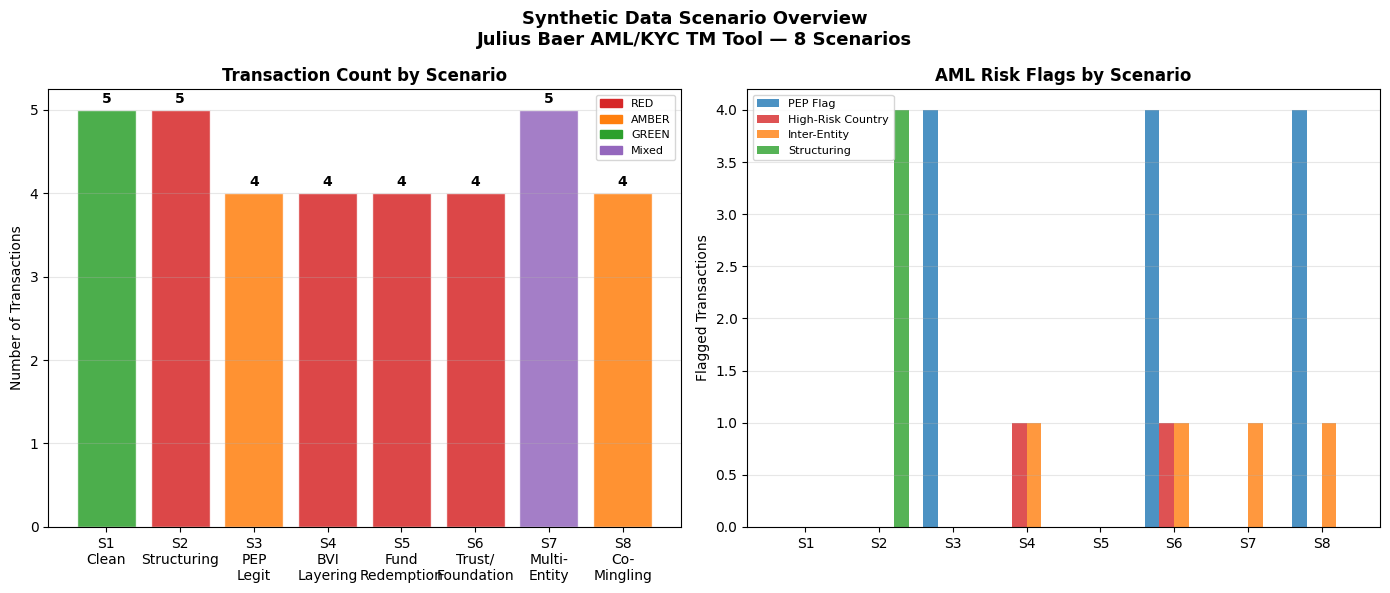

Chart saved → c:\Users\User\Downloads\Assignment 1_G2508087C\outputs\Task3_ScenarioOverview.png


In [ ]:
# SCENARIO OVERVIEW CHART
scenario_ids  = ['S1','S2','S3','S4','S5','S6','S7','S8']
bar_colors    = ['#2ca02c','#d62728','#ff7f0e','#d62728','#d62728','#d62728','#9467bd','#ff7f0e']
scenario_labels = ['S1\nClean','S2\nStructuring','S3\nPEP\nLegit','S4\nBVI\nLayering',
                   'S5\nFund\nRedemption','S6\nTrust/\nFoundation','S7\nMulti-\nEntity','S8\nCo-\nMingling']
counts = [all_scenarios[all_scenarios['scenario']==s].shape[0] for s in scenario_ids]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Synthetic Data Scenario Overview\nJulius Baer AML/KYC TM Tool — 8 Scenarios',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
bars = ax1.bar(scenario_labels, counts, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, str(count),
             ha='center', va='bottom', fontweight='bold')
ax1.set_title('Transaction Count by Scenario', fontweight='bold')
ax1.set_ylabel('Number of Transactions')
ax1.grid(axis='y', alpha=0.3)
handles = [mpatches.Patch(color=c, label=l) for c,l in
           [('#d62728','RED'),('#ff7f0e','AMBER'),('#2ca02c','GREEN'),('#9467bd','Mixed')]]
ax1.legend(handles=handles, fontsize=8)

ax2 = axes[1]
flag_data = all_scenarios.groupby('scenario').agg(
    pep           = ('is_pep','sum'),
    high_risk_cp  = ('is_high_risk_cp_country','sum'),
    inter_entity  = ('is_inter_entity','sum'),
    structuring   = ('is_structured_attempt','sum')
).reindex(scenario_ids).fillna(0)
x, w = np.arange(len(scenario_ids)), 0.2
ax2.bar(x-1.5*w, flag_data['pep'],         w, label='PEP Flag',          color='#1f77b4', alpha=0.8)
ax2.bar(x-0.5*w, flag_data['high_risk_cp'],w, label='High-Risk Country', color='#d62728', alpha=0.8)
ax2.bar(x+0.5*w, flag_data['inter_entity'],w, label='Inter-Entity',      color='#ff7f0e', alpha=0.8)
ax2.bar(x+1.5*w, flag_data['structuring'], w, label='Structuring',       color='#2ca02c', alpha=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(scenario_ids)
ax2.set_title('AML Risk Flags by Scenario', fontweight='bold')
ax2.set_ylabel('Flagged Transactions')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, 'Task3_ScenarioOverview.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved → {chart_path}')

---
## Scenario → Presentation Slide Mapping

| Scenario | Slide | What It Proves |
|---|---|---|
| S1 Clean | Tool does not over-fire | Correctly passes clean HNWI transactions |
| S2 Structuring | Jurisdiction divergence | US CTR mandatory; SG risk narrative — same transactions, different obligations |
| S3 PEP Legitimate | False positive risk | EDD required but no auto-file; human judgement preserved |
| S4 BVI Layering | Why private bank ≠ retail | Entity linkage catches what retail tools miss entirely |
| S5 Fund Redemption | Why ML + rules | Anomaly detection catches typologies with no existing rule |
| S6 Trust/Foundation | BO threshold US vs SG | BO 15% passes FinCEN; fails MAS high-risk threshold |
| S7 Multi-Entity | Full private bank reality | 1 client, 5 accounts, 3 jurisdictions, 1 tool |
| S8 Domestic PEP | Jurisdiction divergence | SG flags it; US does not — config switches automatically |

---
**Done. Run `Task3_JuliusBaer_AML_TM_Tool.ipynb` next.**